# Switcher Two-Step Inference (Single 256x256 Tile)

This notebook shows one complete inference pass with the current best switcher bundle and generated-target manifest.

It is split into:
- **Step A**: shared encoder embedding + switcher routing/selection.
- **Step B**: decoder inference for all experts using the same embedding.


## Training Strategy

- The MoE uses one **shared encoder** and one **switcher** (routing head).
- During switcher-only training, the encoder and all decoders are frozen.
- The switcher predicts multi-label routing targets (expert activation probabilities).
- The best bundle used here is selected from the latest completed runs.


## How The Dataset Targets Were Created

- Routerset samples were normalized to the canonical training tensor shape (`8x256x256`).
- Larger source patches were tiled to deterministic `256x256` windows.
- Routing targets were generated by running expert models and writing `routing_target` in the manifest.
- This notebook reads the generated-target materialized manifest (`manifest_256.jsonl`).


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch

sys.path.insert(0, str(Path("src").resolve()))

from hydranet import load_student_moe_bundle
from hydranet.moe_training import RoutersetMoEDataset

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.grid"] = False

BUNDLE_CANDIDATES = [
    Path("outputs/moe/switcher/best_switcher_20260324_0815/student_moe_bundle.pt"),
    Path("outputs/moe/switcher/best_switcher_20260324_0011/student_moe_bundle.pt"),
]
MANIFEST_PATH = Path("outputs/moe/prefight_gpu_localmanifest_20260323_180018/routerset_materialized/manifest_256.jsonl")
ROUTERSET_DIR = Path("routerset")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def first_existing(paths):
    for path in paths:
        if path.exists():
            return path
    raise FileNotFoundError(f"None of the bundle candidates exists: {paths}")


def to_pseudorgb(chw, channels=(0, 1, 2)):
    rgb = chw[list(channels)].detach().cpu().float().numpy()
    lo = np.percentile(rgb, 2, axis=(1, 2), keepdims=True)
    hi = np.percentile(rgb, 98, axis=(1, 2), keepdims=True)
    rgb = np.clip((rgb - lo) / (hi - lo + 1e-6), 0.0, 1.0)
    return np.transpose(rgb, (1, 2, 0))


def format_multihot(target, names):
    idx = [i for i, v in enumerate(target.tolist()) if float(v) >= 0.5]
    return [names[i] for i in idx]


In [2]:
bundle_path = first_existing(BUNDLE_CANDIDATES)
model = load_student_moe_bundle(bundle_path, map_location=str(DEVICE)).to(DEVICE).eval()

dataset = RoutersetMoEDataset(
    str(ROUTERSET_DIR),
    manifest_path=MANIFEST_PATH,
    expert_names=model.expert_names,
    split="validation",
    target_size=256,
    target_channels=8,
)

sample_index = next(
    i
    for i, record in enumerate(dataset.records)
    if tuple(record.tile_size) == (256, 256) and record.record_status == "positive"
)

record = dataset.records[sample_index]
sample = dataset[sample_index]
image = sample["image"].unsqueeze(0).to(DEVICE)
target = sample["target"]

assert tuple(image.shape[-2:]) == (256, 256), f"Unexpected tile size: {tuple(image.shape[-2:])}"

print(f"Bundle: {bundle_path}")
print(f"Manifest: {MANIFEST_PATH}")
print(f"Device: {DEVICE}")
print(f"Sample index: {sample_index}")
print(f"Sample id: {record.source_sample_id}")
print(f"Source dataset: {record.source_dataset}")
print(f"Tile origin: {record.tile_origin}, tile size: {record.tile_size}")
print(f"Ground-truth routing experts: {format_multihot(target, model.expert_names)}")
print(f"Expert order: {model.expert_names}")


Bundle: outputs/moe/switcher/best_switcher_20260324_0815/student_moe_bundle.pt
Manifest: outputs/moe/prefight_gpu_localmanifest_20260323_180018/routerset_materialized/manifest_256.jsonl
Device: cuda
Sample index: 0
Sample id: 0000001_tile_0_0
Source dataset: anomaly_detection
Tile origin: [0, 0], tile size: [256, 256]
Ground-truth routing experts: ['anomaly_detection', 'fire', 'worldfloods']
Expert order: ['anomaly_detection', 'burned_area', 'fire', 'lc', 'roads', 'worldfloods']


## Step A: Embedding + Switcher Selection

This step computes the shared encoder bottleneck tensor, pools it into the embedding sent to the switcher head, and then obtains routing probabilities and selected experts.


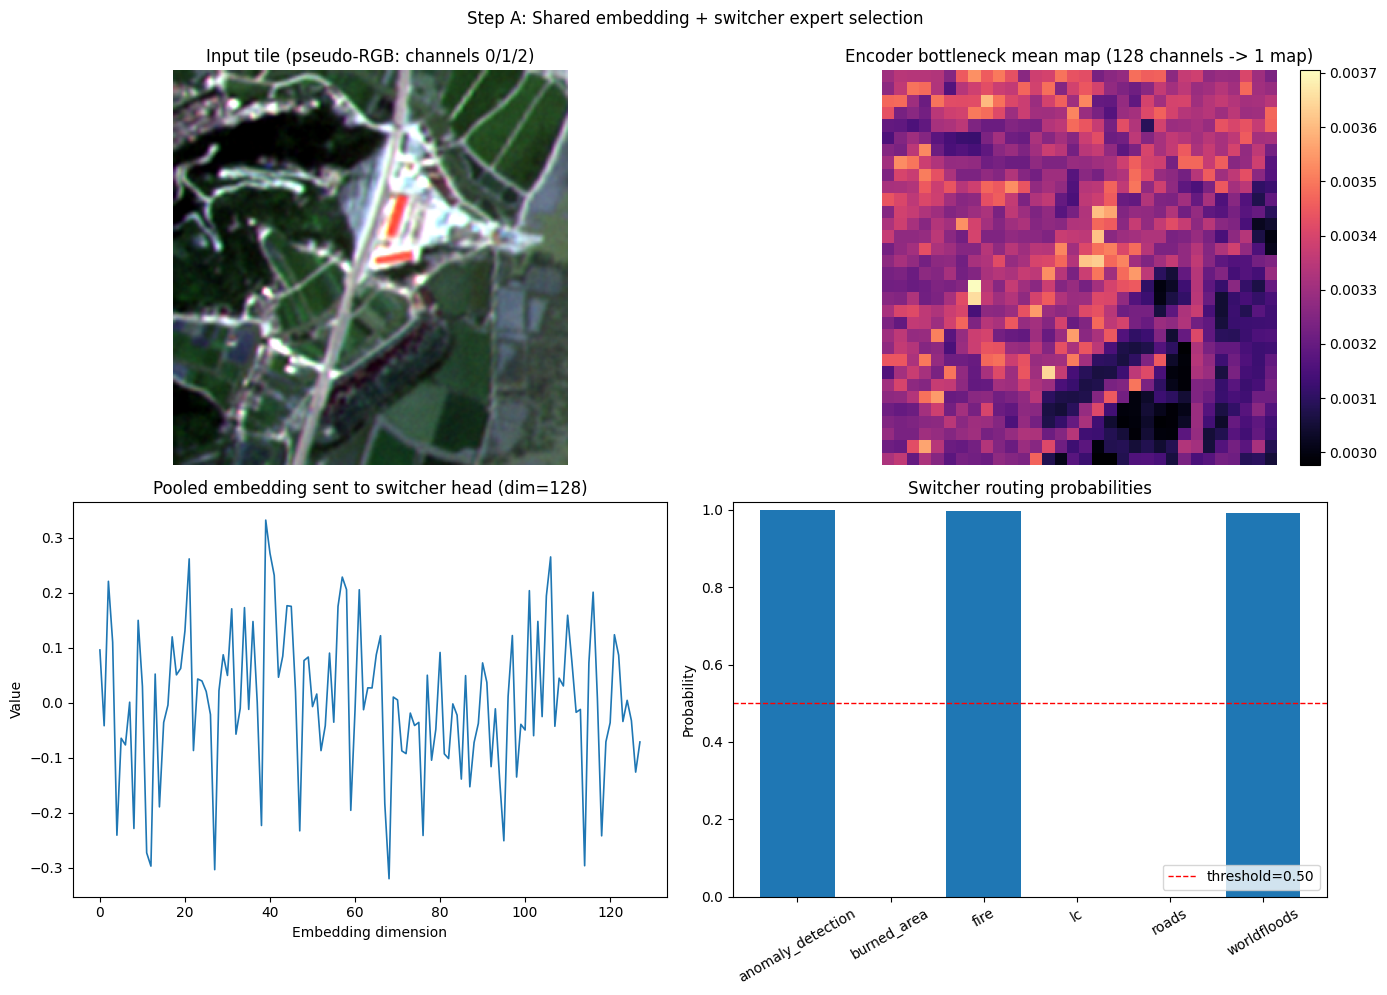

Ground-truth routing experts: ['anomaly_detection', 'fire', 'worldfloods']
Predicted active experts: ['anomaly_detection', 'fire', 'worldfloods']
Top experts (sorted): [('anomaly_detection', 1.0), ('fire', 0.9981998205184937), ('worldfloods', 0.9914140701293945)]
Embedding summary: {'shape': (1, 128), 'min': -0.31979233026504517, 'max': 0.33232027292251587, 'mean': 0.0032764370553195477, 'std': 0.1341402381658554}


In [3]:
with torch.no_grad():
    bottleneck, skip_connections = model.encoder(image)
    pooled_embedding = model.switcher.pool(bottleneck).flatten(1)
    routing_logits = model.switcher(bottleneck)
    routing_probs = torch.sigmoid(routing_logits)
    _, routed_experts = model.route(routing_logits)

embedding_vector = pooled_embedding[0].detach().cpu().numpy()
embedding_map = bottleneck[0].detach().cpu().mean(dim=0).numpy()
probs_np = routing_probs[0].detach().cpu().numpy()

ranked = sorted(
    [(name, float(probs_np[i])) for i, name in enumerate(model.expert_names)],
    key=lambda x: x[1],
    reverse=True,
)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.reshape(-1)

axes[0].imshow(to_pseudorgb(image[0].cpu()))
axes[0].set_title("Input tile (pseudo-RGB: channels 0/1/2)")
axes[0].axis("off")

im = axes[1].imshow(embedding_map, cmap="magma")
axes[1].set_title(f"Encoder bottleneck mean map ({bottleneck.shape[1]} channels -> 1 map)")
axes[1].axis("off")
fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

axes[2].plot(np.arange(embedding_vector.shape[0]), embedding_vector, linewidth=1.2)
axes[2].set_title(f"Pooled embedding sent to switcher head (dim={embedding_vector.shape[0]})")
axes[2].set_xlabel("Embedding dimension")
axes[2].set_ylabel("Value")

axes[3].bar(model.expert_names, probs_np, color="#1f77b4")
axes[3].axhline(
    model.threshold,
    color="red",
    linestyle="--",
    linewidth=1.0,
    label=f"threshold={model.threshold:.2f}",
)
axes[3].set_ylim(0.0, 1.02)
axes[3].set_title("Switcher routing probabilities")
axes[3].set_ylabel("Probability")
axes[3].tick_params(axis="x", rotation=30)
axes[3].legend(loc="lower right")

plt.suptitle("Step A: Shared embedding + switcher expert selection", y=0.99)
plt.tight_layout()
plt.show()

print("Ground-truth routing experts:", format_multihot(target, model.expert_names))
print("Predicted active experts:", routed_experts[0])
print("Top experts (sorted):", ranked[:3])
print(
    "Embedding summary:",
    {
        "shape": tuple(pooled_embedding.shape),
        "min": float(embedding_vector.min()),
        "max": float(embedding_vector.max()),
        "mean": float(embedding_vector.mean()),
        "std": float(embedding_vector.std()),
    },
)


## Step B: Decoder Inference And Plots

This step reuses the same encoder embedding/skip tensors and runs **all** decoder experts, then plots one map per expert.


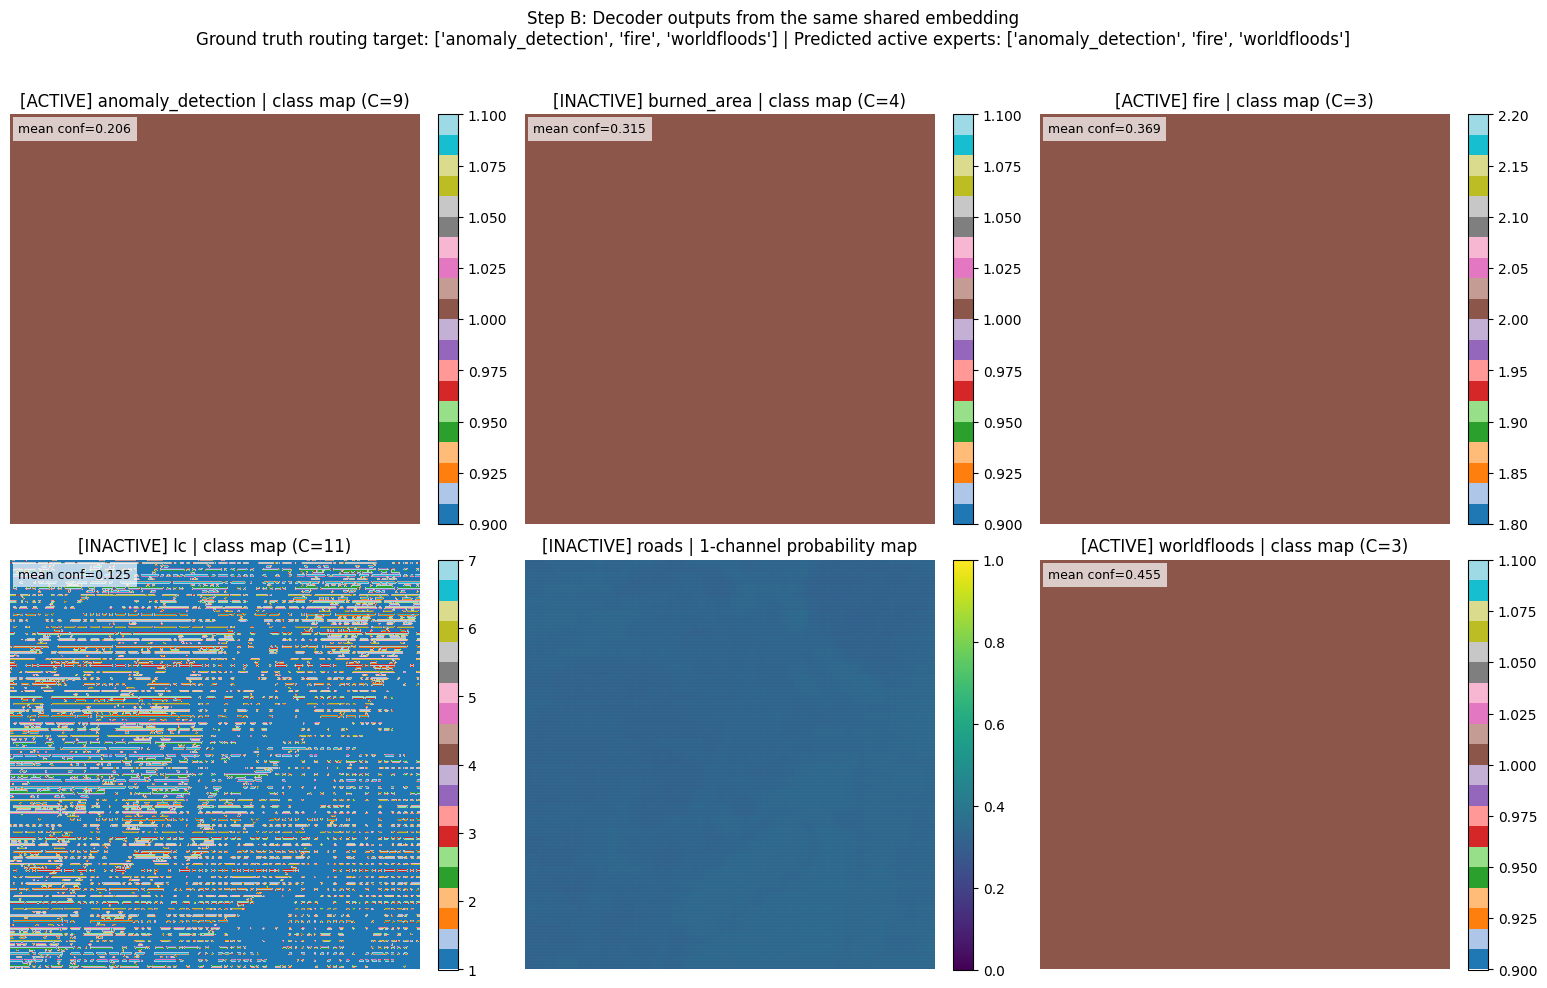

In [4]:
with torch.no_grad():
    bottleneck, skip_connections = model.encoder(image)
    decoder_outputs = {
        name: expert(bottleneck, skip_connections)[0].detach().cpu()
        for name, expert in model.experts.items()
    }

n_experts = len(model.expert_names)
ncols = 3
nrows = int(np.ceil(n_experts / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5.2 * ncols, 4.8 * nrows))
axes = np.array(axes).reshape(-1)

active_set = set(routed_experts[0])

for ax, expert_name in zip(axes, model.expert_names):
    out = decoder_outputs[expert_name]
    channels, _, _ = out.shape
    state = "ACTIVE" if expert_name in active_set else "INACTIVE"

    if channels == 1:
        score = torch.sigmoid(out[0]).numpy()
        im = ax.imshow(score, cmap="viridis", vmin=0.0, vmax=1.0)
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        ax.set_title(f"[{state}] {expert_name} | 1-channel probability map")
    else:
        probs = torch.softmax(out, dim=0)
        pred = torch.argmax(probs, dim=0).numpy()
        conf = torch.max(probs, dim=0).values.numpy()
        im = ax.imshow(pred, cmap="tab20")
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        ax.set_title(f"[{state}] {expert_name} | class map (C={channels})")
        ax.text(
            0.02,
            0.98,
            f"mean conf={conf.mean():.3f}",
            transform=ax.transAxes,
            va="top",
            ha="left",
            fontsize=9,
            bbox={"facecolor": "white", "alpha": 0.7, "edgecolor": "none"},
        )

    ax.axis("off")

for ax in axes[n_experts:]:
    ax.axis("off")

gt_experts = format_multihot(target, model.expert_names)
plt.suptitle(
    "Step B: Decoder outputs from the same shared embedding\n"
    f"Ground truth routing target: {gt_experts} | Predicted active experts: {routed_experts[0]}",
    y=1.02,
)
plt.tight_layout()
plt.show()


## Interpretation

- Step A shows the exact representation sent from the encoder path into the switcher head.
- Step B shows what each decoder produces from that same representation.
- Because this notebook uses one deterministic validation tile (`256x256`), it is easy to inspect routing and decoder behavior side by side.
